In [ ]:
# import xarray as xr
# import numpy as np

# print("Drive mounted. Starting the ultimate 3-way data merge...")

# # ==========================================
# # STEP 1: DEFINE ALL THREE FOLDER PATHS
# # (Pre-filled based on your screenshot!)
# # ==========================================
# imd_path = '/content/drive/MyDrive/Colab Notebooks/#11 Project/Rainfall IMD/*.nc'
# era5_surface_path = '/content/drive/MyDrive/Colab Notebooks/#11 Project/ERA5 Data/*.nc'
# era5_humidity_path = '/content/drive/MyDrive/Colab Notebooks/#11 Project/ERA5 Humidity/*.nc'

# # ==========================================
# # STEP 2: LOAD & CROP THE IMD TARGET DATA (y)
# # ==========================================
# print("1. Processing IMD Rainfall...")
# ds_imd = xr.open_mfdataset(imd_path, combine='by_coords')
# # Crop to Mahanadi Basin
# ds_imd_cropped = ds_imd.sel(LATITUDE=slice(17.0, 24.5), LONGITUDE=slice(80.0, 87.5))
# y_target = ds_imd_cropped['RAINFALL'].values

# # ==========================================
# # STEP 3: LOAD ERA5 SURFACE DATA (Temp, Pressure, Wind)
# # ==========================================
# print("2. Processing ERA5 Surface Features...")
# ds_surface = xr.open_mfdataset(era5_surface_path, combine='by_coords')
# ds_surface = ds_surface.sortby('latitude').sortby('longitude')

# temp = ds_surface['t2m'].values
# pressure = ds_surface['msl'].values
# u_wind = ds_surface['u10'].values
# v_wind = ds_surface['v10'].values

# # ==========================================
# # STEP 4: LOAD ERA5 CLOUD HUMIDITY DATA
# # ==========================================
# print("3. Processing ERA5 Cloud Humidity...")
# ds_humidity = xr.open_mfdataset(era5_humidity_path, combine='by_coords')
# ds_humidity = ds_humidity.sortby('latitude').sortby('longitude')

# # We use .squeeze() because the 850hPa pressure level adds an empty dimension.
# # Squeeze flattens it so it matches the shape of the surface variables perfectly!
# humidity = ds_humidity['q'].squeeze().values

# # ==========================================
# # STEP 5: THE FINAL 5-CHANNEL SANDWICH (X)
# # ==========================================
# print("4. Stacking all 5 variables into the final tensor...")
# X_features = np.stack([temp, pressure, humidity, u_wind, v_wind], axis=-1)

# # ==========================================
# # STEP 6: VERIFICATION
# # ==========================================
# print("\n✅ ULTIMATE DATA ENGINEERING COMPLETE!")
# print(f"Target (Rainfall) Shape: {y_target.shape}")
# print(f"Features (Weather) Shape: {X_features.shape}")

# if y_target.shape[0] == X_features.shape[0] and y_target.shape[1:3] == X_features.shape[1:3]:
#     print("🚀 Shapes match perfectly. You are 100% ready to build the CNN-LSTM!")
# else:
#     print("⚠️ Warning: Shapes do not match. Check your coordinates!")

Drive mounted. Starting the ultimate 3-way data merge...
1. Processing IMD Rainfall...
2. Processing ERA5 Surface Features...
3. Processing ERA5 Cloud Humidity...
4. Stacking all 5 variables into the final tensor...

✅ ULTIMATE DATA ENGINEERING COMPLETE!
Target (Rainfall) Shape: (7670, 31, 31)
Features (Weather) Shape: (7670, 31, 31, 5)
🚀 Shapes match perfectly. You are 100% ready to build the CNN-LSTM!


In [ ]:
# import numpy as np
# import os

# # main project folder path
# save_path = '/content/drive/MyDrive/Colab Notebooks/#11 Project/'
# master_file = os.path.join(save_path, 'Mahanadi_DeepLearning_Data.npz')

# print("Compressing and saving all data into ONE master file...")
# print("This might take a minute or two, please wait...")

# # np.savez_compressed takes multiple arrays and zips them into one file.
# # We are naming the arrays 'X' and 'y' inside the file so they are easy to grab later!
# np.savez_compressed(master_file, X=X_features, y=y_target)

# print("✅ Success! Your entire 21-year dataset is locked inside: Mahanadi_DeepLearning_Data.npz")
# print("You never have to run the NetCDF merge scripts again.")

Compressing and saving all data into ONE master file...
This might take a minute or two, please wait...
✅ Success! Your entire 21-year dataset is locked inside: Mahanadi_DeepLearning_Data.npz
You never have to run the NetCDF merge scripts again.


RUN
**RUN**
<h1 color='red'>RUN</H1>


In [5]:
import numpy as np


# dataset = np.load('/content/drive/MyDrive/Colab Notebooks/#11 Project/Mahanadi_DeepLearning_Data.npz')
dataset = np.load('/kaggle/input/datasets/pulkitkumarpkpk/mahanadi-rainfall/Mahanadi_DeepLearning_Data (2).npz')
# Extract X and y
X_features = dataset['X']
y_target = dataset['y']

In [6]:
import numpy as np

print("--- STEP 1: DATA HEALTH CHECK ---")

# Load dataset
file_path = '/kaggle/input/datasets/pulkitkumarpkpk/mahanadi-rainfall/Mahanadi_DeepLearning_Data (2).npz'
dataset = np.load(file_path)

# Extract X and y.
X = dataset['X'].copy()
y = dataset['y'].copy()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Count exactly how many NaNs (missing values) are hiding in the billions of pixels
nan_count_X = np.isnan(X).sum()
nan_count_y = np.isnan(y).sum()

print(f"\nMissing values (NaNs) in Weather Features (X): {nan_count_X}")
print(f"Missing values (NaNs) in Rainfall Target (y): {nan_count_y}")

--- STEP 1: DATA HEALTH CHECK ---
Features (X) shape: (7670, 31, 31, 5)
Target (y) shape: (7670, 31, 31)

Missing values (NaNs) in Weather Features (X): 0
Missing values (NaNs) in Rainfall Target (y): 1518660


In [7]:
import numpy as np

print("--- REVISED STEP 2: WINSORIZE FIRST, THEN FILL NANS ---")

# 1. Calculate the 99th percentile ONLY on valid land pixels (ignoring ocean NaNs)
upper_limit = np.nanpercentile(y, 99)
print(f"Calculated 99th percentile limit: {upper_limit:.2f} mm")

# 2. Clip the extreme outliers (the ocean NaNs safely stay as NaNs during this step)
y_clipped = np.clip(y, a_min=0, a_max=upper_limit)

# 3. NOW it is safe to convert those 1.5 million ocean NaNs to 0.0
y_clean = np.nan_to_num(y_clipped, nan=0.0)

# 4. Final Verification
print(f"\nRemaining NaNs in y_clean: {np.isnan(y_clean).sum()}")
print(f"Max rainfall AFTER cleaning: {np.max(y_clean):.2f} mm")
print(f"Final shape of y_clean: {y_clean.shape}")

--- REVISED STEP 2: WINSORIZE FIRST, THEN FILL NANS ---
Calculated 99th percentile limit: 53.12 mm

Remaining NaNs in y_clean: 0
Max rainfall AFTER cleaning: 53.12 mm
Final shape of y_clean: (7670, 31, 31)


In [8]:
# Overwrite the original target array with the cleaned version
y = y_clean.copy()

In [9]:
nan_count_X = np.isnan(X).sum()
nan_count_y = np.isnan(y).sum()
print(f"\nMissing values (NaNs) in Weather Features (X): {nan_count_X}")
print(f"Missing values (NaNs) in Rainfall Target (y): {nan_count_y}")


Missing values (NaNs) in Weather Features (X): 0
Missing values (NaNs) in Rainfall Target (y): 0


In [6]:
# from sklearn.preprocessing import MinMaxScaler
# import numpy as np

# print("--- STEP 4: SPATIOTEMPORAL FEATURE SCALING ---")

# # 1. Initialize separate scalers for X and y
# # CRITICAL: We keep the y scaler separate so you can inverse_transform
# # your model's future predictions back into actual millimeters of rainfall later!
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# # 2. Scale the X features (Shape: 7670, 31, 31, 5)
# print("Scaling weather features (X)...")
# original_X_shape = X.shape

# # Temporarily flatten to (Total_Pixels_Across_All_Days, 5 features)
# X_flat = X.reshape(-1, original_X_shape[-1])
# X_scaled_flat = scaler_X.fit_transform(X_flat)

# # Reshape exactly back to the 4D grid
# X_scaled = X_scaled_flat.reshape(original_X_shape)
# print(f"X_scaled shape: {X_scaled.shape}")
# print(f"X_scaled range: [{np.min(X_scaled):.2f}, {np.max(X_scaled):.2f}]")

# # 3. Scale the cleaned target y (Shape: 7670, 31, 31)
# print("\nScaling rainfall target (y_clean)...")
# original_y_shape = y_clean.shape

# # Flatten to a 2D column vector (Total_Pixels, 1)
# y_flat = y_clean.reshape(-1, 1)
# y_scaled_flat = scaler_y.fit_transform(y_flat)

# # Reshape exactly back to the 3D grid
# y_scaled = y_scaled_flat.reshape(original_y_shape)
# print(f"y_scaled shape: {y_scaled.shape}")
# print(f"y_scaled range: [{np.min(y_scaled):.2f}, {np.max(y_scaled):.2f}]")

In [10]:
X.shape

(7670, 31, 31, 5)

In [11]:
import numpy as np

# Create the 1D coordinate arrays
# np.linspace ensures we get exactly 31 points between the start and end
lats = np.linspace(17.0, 24.5, 31)
lons = np.linspace(80.0, 87.5, 31)

print(f"Latitude range: {lats[0]} to {lats[-1]}")
print(f"Longitude range: {lons[0]} to {lons[-1]}")
print(f"Resolution: {lats[1] - lats[0]} degrees per pixel")

Latitude range: 17.0 to 24.5
Longitude range: 80.0 to 87.5
Resolution: 0.25 degrees per pixel


In [12]:
# Create a 2D grid of coordinates
lon_2d, lat_2d = np.meshgrid(lons, lats)

# Now, lat_2d[i, j] and lon_2d[i, j] give you the
# exact geographic location of the pixel at index [i, j]
print(f"Shape of coordinate grids: {lat_2d.shape}")

Shape of coordinate grids: (31, 31)


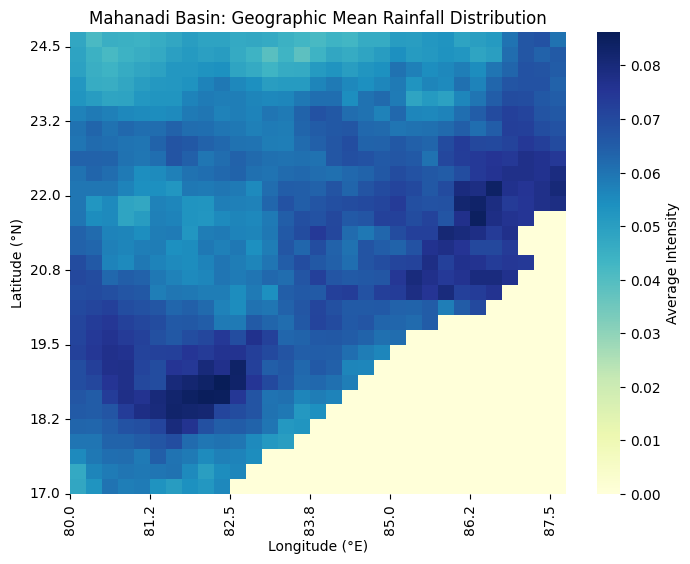

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))

# 1. Use MEAN to see the whole basin shape, not just one day
mean_map = np.mean(y_scaled, axis=0)

# 2. Plotting with labels
sns.heatmap(mean_map,
            xticklabels=np.round(lons, 2),
            yticklabels=np.round(lats, 2),
            cmap="YlGnBu",
            cbar_kws={'label': 'Average Intensity'})

# 3. Clean up labels (show every 5th)
plt.xticks(np.arange(0, 31, 5), np.round(lons[::5], 1))
plt.yticks(np.arange(0, 31, 5), np.round(lats[::5], 1))

# 4. CRITICAL: Invert the axis so 24.5N is at the top and 17.0N is at the bottom
plt.gca().invert_yaxis()

plt.title("Mahanadi Basin: Geographic Mean Rainfall Distribution")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.show()

Total 'No-Rain' (Ocean/Background) Pixels: 198

--- First 10 No-Rain Coordinates ---
   Lat_Index  Lon_Index  Latitude_Deg  Longitude_Deg
0          0         10          17.0          82.50
1          0         11          17.0          82.75
2          0         12          17.0          83.00
3          0         13          17.0          83.25
4          0         14          17.0          83.50
5          0         15          17.0          83.75
6          0         16          17.0          84.00
7          0         17          17.0          84.25
8          0         18          17.0          84.50
9          0         19          17.0          84.75


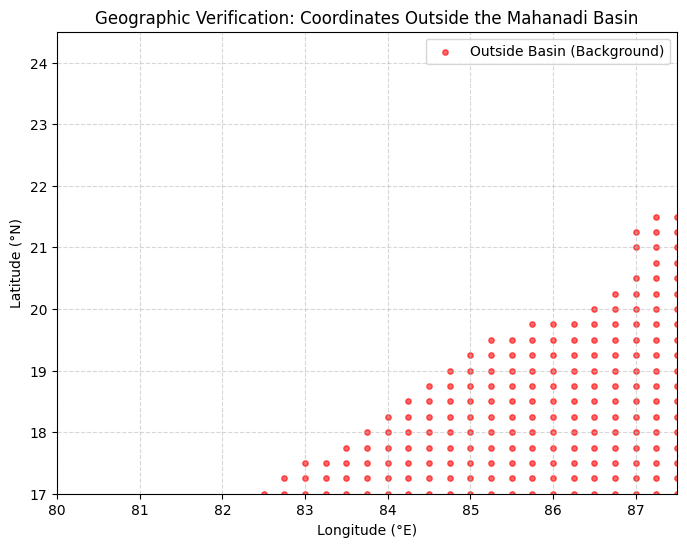

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Identify the 'No-Rain' Mask
# We look for pixels where the maximum value over all 7670 days is exactly 0
no_rain_mask = np.max(y_scaled, axis=0) == 0

# 2. Get the matrix indices (row, col) for these pixels
no_rain_indices = np.argwhere(no_rain_mask)

# 3. Convert Indices to Real-World Degrees
# Based on your crop: Lat (17.0 to 24.5) and Lon (80.0 to 87.5)
# Resolution is (24.5 - 17.0) / 30 = 0.25 degrees
basin_no_rain_coords = []

for i, j in no_rain_indices:
    # Latitude formula: Start + (Index * Resolution)
    lat = 17.0 + (i * 0.25)
    # Longitude formula: Start + (Index * Resolution)
    lon = 80.0 + (j * 0.25)

    basin_no_rain_coords.append({
        'Lat_Index': i,
        'Lon_Index': j,
        'Latitude_Deg': round(lat, 2),
        'Longitude_Deg': round(lon, 2)
    })

# 4. Create a DataFrame for easy viewing/export
df_no_rain = pd.DataFrame(basin_no_rain_coords)

print(f"Total 'No-Rain' (Ocean/Background) Pixels: {len(df_no_rain)}")
print("\n--- First 10 No-Rain Coordinates ---")
print(df_no_rain.head(10))

# --- OPTIONAL: Visual Validation Plot ---
plt.figure(figsize=(8, 6))

# Plotting the 'No-Rain' coordinates in red
plt.scatter(df_no_rain['Longitude_Deg'], df_no_rain['Latitude_Deg'],
            color='red', s=15, alpha=0.6, label='Outside Basin (Background)')

# Setting plot limits based on your original crop
plt.xlim(80.0, 87.5)
plt.ylim(17.0, 24.5)

plt.title("Geographic Verification: Coordinates Outside the Mahanadi Basin")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

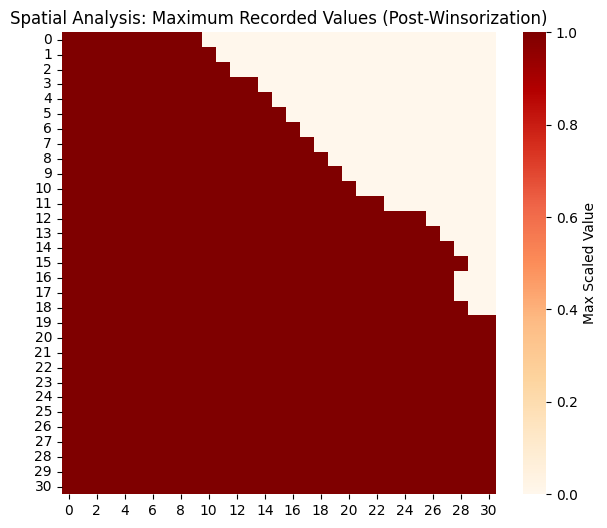

In [ ]:
plt.figure(figsize=(7, 6))
max_map = np.max(y_scaled, axis=0)

sns.heatmap(max_map, cmap="OrRd", cbar_kws={'label': 'Max Scaled Value'})
plt.title("Spatial Analysis: Maximum Recorded Values (Post-Winsorization)")
plt.show()

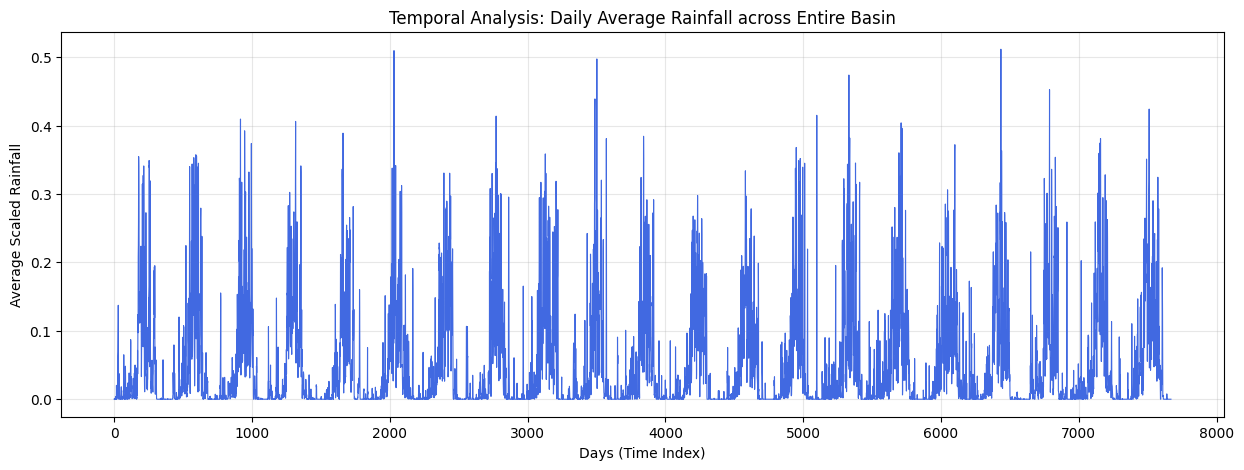

In [ ]:
plt.figure(figsize=(15, 5))
# Average across the spatial dimensions (axis 1 and 2)
basin_timeline = np.mean(y_scaled, axis=(1, 2))

plt.plot(basin_timeline, color='royalblue', linewidth=0.8)
plt.title("Temporal Analysis: Daily Average Rainfall across Entire Basin")
plt.ylabel("Average Scaled Rainfall")
plt.xlabel("Days (Time Index)")
plt.grid(alpha=0.3)
plt.show()

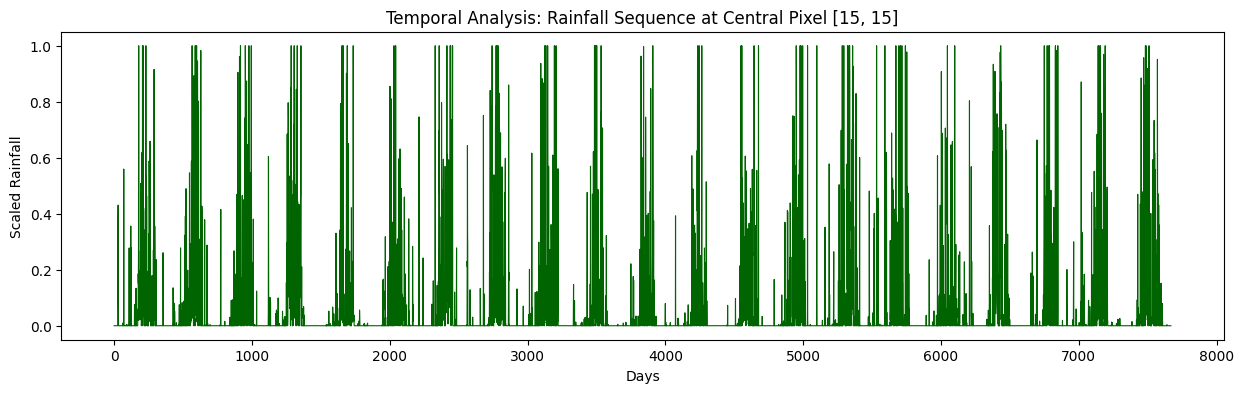

In [ ]:
plt.figure(figsize=(15, 4))
# Change [15, 15] to any coordinate to see different parts of the basin
plt.plot(y_scaled[:, 15, 15], color='darkgreen', linewidth=0.8)
plt.title("Temporal Analysis: Rainfall Sequence at Central Pixel [15, 15]")
plt.ylabel("Scaled Rainfall")
plt.xlabel("Days")
plt.show()

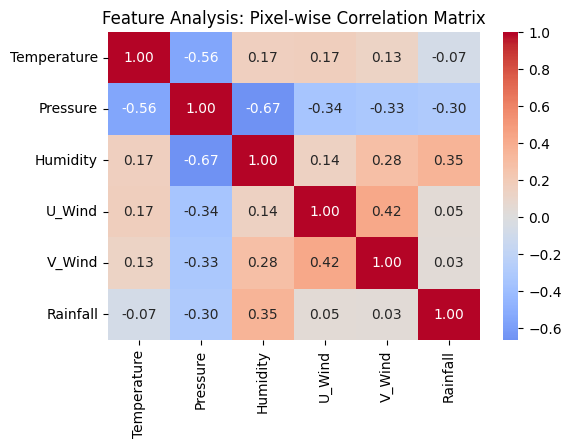

In [ ]:
import pandas as pd

# Flatten the spatial dimensions to treat every pixel-day as a sample
X_flattened = X_scaled.reshape(-1, 5)
y_flattened = y_scaled.reshape(-1, 1)

# Create a temporary dataframe for correlation
# features_list = ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Rainfall']
features_list = ['Temperature', 'Pressure', 'Humidity', 'U_Wind', 'V_Wind', 'Rainfall']
df_corr = pd.DataFrame(np.hstack([X_flattened, y_flattened]), columns=features_list)

plt.figure(figsize=(6, 4))
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Feature Analysis: Pixel-wise Correlation Matrix")
plt.show()

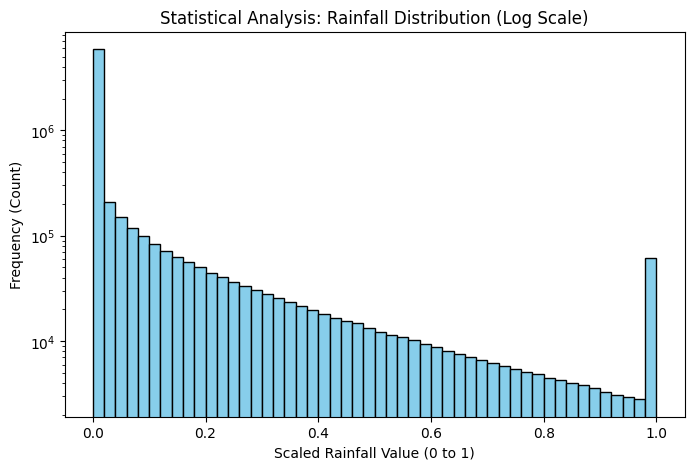

In [ ]:
plt.figure(figsize=(8, 5))
# Use log=True because the number of 0.0 values will be massive compared to wet days
plt.hist(y_scaled.flatten(), bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Statistical Analysis: Rainfall Distribution (Log Scale)")
plt.xlabel("Scaled Rainfall Value (0 to 1)")
plt.ylabel("Frequency (Count)")
plt.show()

--- METHOD 1: CORRELATION ANALYSIS ---


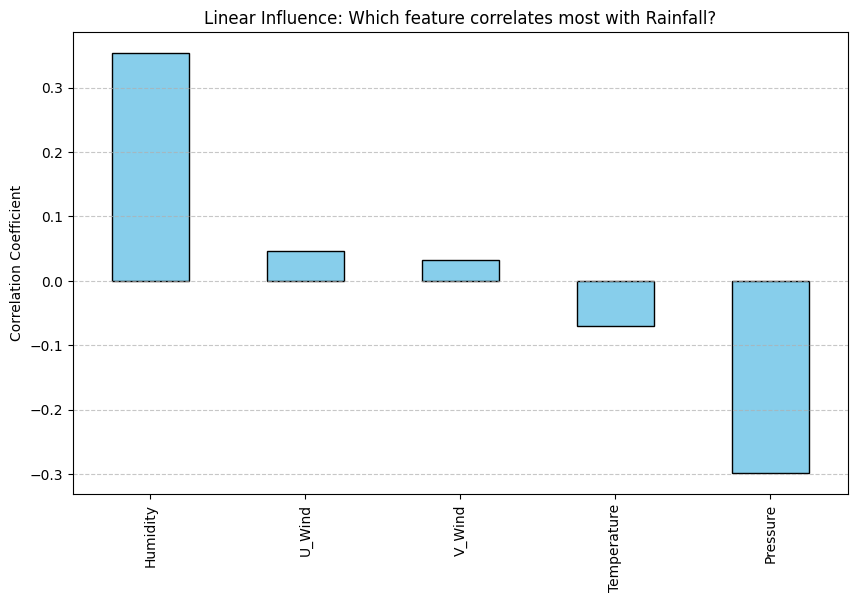

Top Influencer (Linear): Humidity


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("--- METHOD 1: CORRELATION ANALYSIS ---")

# 1. Flatten the spatial grid (31x31) so every pixel is a row
# X shape: (7670, 31, 31, 5) -> (7670 * 31 * 31, 5)
X_flat_influence = X_scaled.reshape(-1, 5)
# y shape: (7670, 31, 31) -> (7670 * 31 * 31, 1)
y_flat_influence = y_scaled.reshape(-1, 1)

# 2. Create a temporary DataFrame for analysis
# Replace F1-F5 with your actual feature names (e.g., Temp, Humidity, Pressure)
feature_names = ['Temperature', 'Pressure', 'Humidity', 'U_Wind', 'V_Wind']
df_influence = pd.DataFrame(X_flat_influence, columns=feature_names)
df_influence['Rainfall'] = y_flat_influence

# 3. Calculate and Plot Correlation
plt.figure(figsize=(10, 6))
correlations = df_influence.corr()['Rainfall'].sort_values(ascending=False).drop('Rainfall')
correlations.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Linear Influence: Which feature correlates most with Rainfall?")
plt.ylabel("Correlation Coefficient")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Top Influencer (Linear):", correlations.index[0])

array([ 3.01583252e+02,  1.01235625e+05,  8.55877716e-03, -1.57385254e+00,
        1.26586914e+00], dtype=float32)

--- PLOTTING SPECIFIC YEAR: 2025 ---


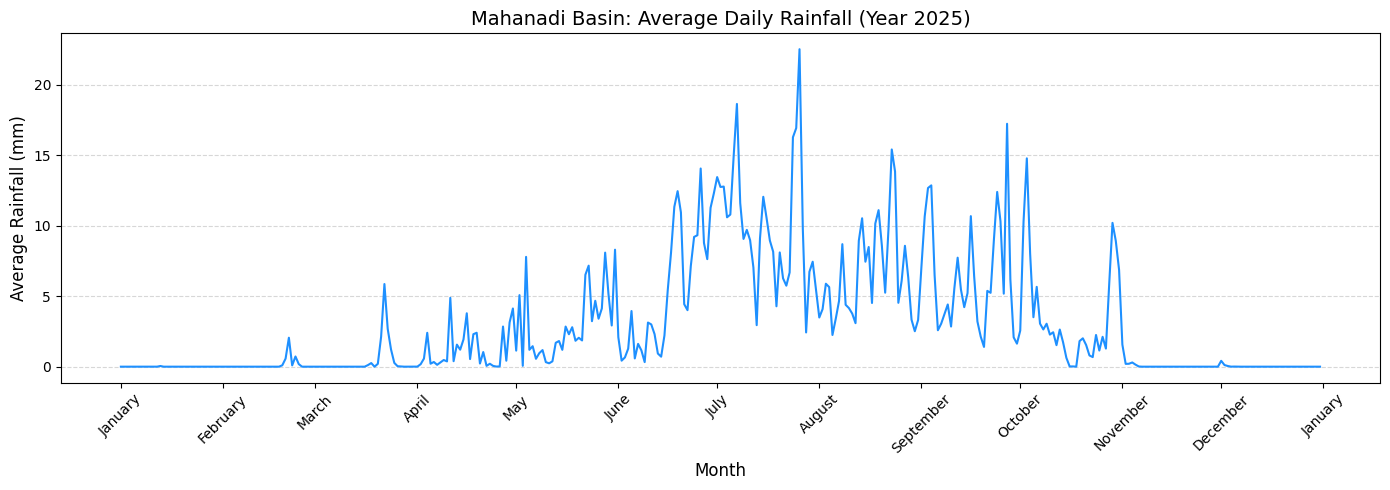

Total rain days recorded in 2025: 249
Maximum basin average hit in 2025: 22.53 mm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("--- PLOTTING SPECIFIC YEAR: 2025 ---")

# 1. Generate the exact calendar for your 7670 days
# (If your dataset started on a different day, just change the start date here)
timeline = pd.date_range(start='2005-01-01', periods=7670, freq='D')

# 2. Convert your scaled target back to real millimeters
y_flat_real = scaler_y.inverse_transform(y_scaled.reshape(-1, 1))
y_real_3d = y_flat_real.reshape(y_scaled.shape)

# 3. Calculate the Basin Average (Macro View) in millimeters
basin_avg_mm = np.mean(y_real_3d, axis=(1, 2))

# 4. Bind the dates and the data together in a Pandas DataFrame
df_timeline = pd.DataFrame({
    'Date': timeline,
    'Rainfall_mm': basin_avg_mm
})

# 5. Filter for ONLY the year 2025
df_2025 = df_timeline[df_timeline['Date'].dt.year == 2025]

# 6. Plot the zoomed-in year
plt.figure(figsize=(14, 5))
plt.plot(df_2025['Date'], df_2025['Rainfall_mm'], color='dodgerblue', linewidth=1.5)

# Formatting the plot to look highly professional
plt.title("Mahanadi Basin: Average Daily Rainfall (Year 2025)", fontsize=14)
plt.ylabel("Average Rainfall (mm)", fontsize=12)
plt.xlabel("Month", fontsize=12)

# Make the x-axis show nicely formatted month names
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%B'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Total rain days recorded in 2025: {(df_2025['Rainfall_mm'] > 0).sum()}")
print(f"Maximum basin average hit in 2025: {df_2025['Rainfall_mm'].max():.2f} mm")

In [13]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# DELETE the old Cell 9 scaler entirely — use only this one
total_days = X_features.shape[0]
train_end  = int(total_days * 0.70)
val_end    = int(total_days * 0.85)

X_train_raw = X_features[:train_end]
X_val_raw   = X_features[train_end:val_end]
X_test_raw  = X_features[val_end:]

y_train_raw = y_clean[:train_end]
y_val_raw   = y_clean[train_end:val_end]
y_test_raw  = y_clean[val_end:]

# Fit scalers ONLY on training data — no leakage
scaler_X = RobustScaler()
scaler_y = MinMaxScaler()

def scale_array(arr, scaler, fit=False):
    n_feats = arr.shape[-1] if arr.ndim == 4 else 1
    flat    = arr.reshape(-1, n_feats)
    scaled  = scaler.fit_transform(flat) if fit else scaler.transform(flat)
    return scaled.reshape(arr.shape)

X_train = scale_array(X_train_raw, scaler_X, fit=True)
X_val   = scale_array(X_val_raw,   scaler_X)
X_test  = scale_array(X_test_raw,  scaler_X)

y_train = scale_array(y_train_raw.reshape(*y_train_raw.shape, 1), scaler_y, fit=True).squeeze(-1)
y_val   = scale_array(y_val_raw.reshape(*y_val_raw.shape, 1),     scaler_y).squeeze(-1)
y_test  = scale_array(y_test_raw.reshape(*y_test_raw.shape, 1),   scaler_y).squeeze(-1)

# Add this after Cell 24 to verify no out-of-range values:
print("X_val min/max:", X_val.min(), X_val.max())  # Should be near [0, 1]
print("y_val min/max:", y_val.min(), y_val.max())   # Should be near [0, 1]
# If max >> 1, your scaler is leaking or fitted on wrong data

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

X_val min/max: -10.998178 12.680219
y_val min/max: 0.0 1.0
Train: (5369, 31, 31, 5), Val: (1150, 31, 31, 5), Test: (1151, 31, 31, 5)


In [14]:
def create_sequences_2d(X, y, lookback=7, horizon=3):
    """
    X: (days, 31, 31, 5)
    y: (days, 31, 31)
    Returns:
      X_seq: (samples, lookback, 31, 31, 5)
      y_seq: (samples, horizon, 31, 31)
    """
    Xs, ys,indices = [], [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon])
        indices.append(i + lookback)   # ← record start day
    return np.array(Xs), np.array(ys), np.array(indices)

LOOKBACK  = 7
HORIZON   = 3

X_train_seq, y_train_seq, train_ind = create_sequences_2d(X_train, y_train, LOOKBACK, HORIZON)
X_val_seq,   y_val_seq,var_ind  = create_sequences_2d(X_val,   y_val,   LOOKBACK, HORIZON)
X_test_seq,  y_test_seq,test_ind  = create_sequences_2d(X_test,  y_test,  LOOKBACK, HORIZON)

# X shape: (samples, 7, 31, 31, 5)
# y shape: (samples, 3, 31, 31)
print(f"X_train_seq: {X_train_seq.shape}")
print(f"y_train_seq: {y_train_seq.shape}")

X_train_seq: (5360, 7, 31, 31, 5)
y_train_seq: (5360, 3, 31, 31)


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers
REG = regularizers.l2(1e-4) 

# ── 1. CUSTOM LAYERS (Bypassing Keras Save Bugs) ───────────────────────
class TileHorizon(layers.Layer):
    """Expands a single 2D spatial map into multiple identical future frames."""
    def __init__(self, horizon, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
    def call(self, x):
        return tf.tile(tf.expand_dims(x, 1), [1, self.horizon, 1, 1, 1])
    def get_config(self):
        return {**super().get_config(), 'horizon': self.horizon}

class StackHorizon(layers.Layer):
    """Stacks a 4D spatial tensor across the time dimension."""
    def __init__(self, horizon, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
    def call(self, x):
        return tf.stack([x] * self.horizon, axis=1)
    def get_config(self):
        return {**super().get_config(), 'horizon': self.horizon}

# ── 2. CUSTOM LOSS FUNCTION ─────────────────────────────────────────────
# def weighted_mae(y_true, y_pred):
#     """Forces the AI to care 10x more about extreme rainfall than dry days."""
#     abs_error = tf.abs(y_true - y_pred)
#     is_rain   = tf.cast(y_true > 0.01, tf.float32)
#     weights   = 1.0 + 9.0 * is_rain
#     mse_term  = tf.square(y_true - y_pred) * is_rain
#     return tf.reduce_mean(abs_error * weights) + 0.5 * tf.reduce_mean(mse_term)

# ── 3. THE U-NET ARCHITECTURE ───────────────────────────────────────────
def build_cnn_lstm_unet(lookback=7, h=31, w=31, n_feats=5, horizon=3):
    inp = layers.Input(shape=(lookback, h, w, n_feats))

    # --- ENCODER (Spatial Feature Extraction) ---
    # Encoder — add kernel_regularizer to every Conv2D
    s1 = layers.TimeDistributed(
        layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=REG))(inp)
    s1 = layers.TimeDistributed(layers.BatchNormalization())(s1)
    s1 = layers.TimeDistributed(
        layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=REG))(s1)
    s1 = layers.TimeDistributed(layers.BatchNormalization())(s1)
    
    x = layers.TimeDistributed(layers.MaxPooling2D(2, padding='same'))(s1)
    
    s2 = layers.TimeDistributed(
        layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=REG))(x)
    s2 = layers.TimeDistributed(layers.BatchNormalization())(s2)
    
    # Bottleneck — increase Dropout from 0.3 to 0.4
    x = layers.ConvLSTM2D(128, kernel_size=3, padding='same',
                           return_sequences=False,recurrent_dropout=0.1)(s2)
    x = layers.Dropout(0.4)(x)   # was 0.3
    # x shape: (batch, 16, 16, 128)

    # 2. Duplicate that map into 3 future frames
    x = StackHorizon(horizon)(x)
    # x shape: (batch, 3, 16, 16, 128)

    # 3. Predict how the storm moves across those 3 frames
    x = layers.ConvLSTM2D(128, kernel_size=3, padding='same', return_sequences=True,recurrent_dropout=0.1)(x)
    # x shape: (batch, 3, 16, 16, 128)

    # --- DECODER (Spatial Reconstruction & Fusion) ---
    # Skip S2 fusion
    s2_mean = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(s2) # Grab Day 7
    s2_exp  = TileHorizon(horizon)(s2_mean)                  # Expand to Day 8, 9, 10
    x       = layers.Concatenate(axis=-1)([x, s2_exp])
    # x shape: (batch, 3, 16, 16, 256)

    # Upsampling
    x  = layers.TimeDistributed(
        layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu', kernel_regularizer=REG))(x)
    x  = layers.TimeDistributed(
        layers.Cropping2D(((0, 1), (0, 1))))(x)
    # x shape: (batch, 3, 31, 31, 64)

    # Skip S1 fusion
    s1_mean = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(s1)
    s1_exp  = TileHorizon(horizon)(s1_mean)
    x       = layers.Concatenate(axis=-1)([x, s1_exp])
    # x shape: (batch, 3, 31, 31, 128)

    # Final Polish
    x  = layers.TimeDistributed(
        layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=REG))(x)
    x  = layers.TimeDistributed(
        layers.BatchNormalization())(x)

    # Output Layer
    out = layers.TimeDistributed(
        layers.Conv2D(1, 1, activation='relu'))(x)
    out = layers.Reshape((horizon, h, w))(out)

    return Model(inp, out)

# ── 4. BUILD & COMPILE ──────────────────────────────────────────────────
print("Building Spatial-Temporal U-Net...")
model = build_cnn_lstm_unet()
model.summary()

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss=weighted_mae,
#     metrics=['mae']
# )
# print("✅ Engine built and compiled successfully! Ready for model.fit()")

Building Spatial-Temporal U-Net...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 7, 31, 31, │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_24 │ (None, 7, 31, 31, │      1,472 │ input_layer_2[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_25 │ (None, 7, 31, 31, │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_26 │ (None, 7, 31, 31, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_27 │ (None, 7, 31, 31, │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_28 │ (None, 7, 16, 16, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_29 │ (None, 7, 16, 16, │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_30 │ (None, 7, 16, 16, │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_4       │ (None, 16, 16,    │  1,180,160 │ time_distributed… │
│ (ConvLSTM2D)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ conv_lstm2d_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_horizon_2     │ (None, 3, 16, 16, │          0 │ dropout_2[0][0]   │
│ (StackHorizon)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 16, 16,    │          0 │ time_distributed… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_5       │ (None, 3, 16, 16, │  1,180,160 │ stack_horizon_2[… │
│ (ConvLSTM2D)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tile_horizon_4      │ (None, 3, 16, 16, │          0 │ lambda_4[0][0]    │
│ (TileHorizon)       │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 3, 16, 16, │          0 │ conv_lstm2d_5[0]… │
│ (Concatenate)       │ 256)              │            │ tile_horizon_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_31 │ (None, 3, 32, 32, │    147,520 │ concatenate_4[0]… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 31, 31,    │          0 │ time_distributed

 Total params: 2,639,617 (10.07 MB)

 Trainable params: 2,639,105 (10.07 MB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
import tensorflow as tf

def combined_loss(y_true, y_pred):
    """
    Three-component loss designed for sparse rainfall grids.

    Component A — Balanced MAE:
        Wet and dry pixels each contribute 50% of the loss,
        regardless of how many there are. This kills the
        'predict zero everywhere' shortcut.

    Component B — Wet-pixel intensity MAE:
        Extra penalty specifically on rainy pixels to push
        the model to correctly estimate rainfall amounts,
        not just detect whether it rained.

    Component C — Spatial gradient loss:
        Penalises blurry, spatially uniform predictions by
        comparing the gradient (edge sharpness) of the
        predicted map vs the actual map. This directly
        fights the smearing artifact you see in the output.
    """

    # ── Wet/dry masks ──────────────────────────────────────────
    # Threshold 0.02 in scaled space ≈ ~1 mm in real mm
    # (since scaler_y maps 0–53 mm to 0–1, so 0.02 ≈ 1.06 mm)
    rain_mask = tf.cast(y_true > 0.02, tf.float32)   # 1 where it rains
    dry_mask  = 1.0 - rain_mask                        # 1 where it's dry

    wet_count = tf.reduce_sum(rain_mask) + 1e-6
    dry_count = tf.reduce_sum(dry_mask)  + 1e-6
    total     = wet_count + dry_count

    # ── Component A: Balanced MAE ──────────────────────────────
    # Each wet pixel gets weight = total / (2 * wet_count)
    # Each dry pixel gets weight = total / (2 * dry_count)
    # This guarantees wet pixels collectively == dry pixels collectively
    # in their contribution to the gradient, regardless of counts.
    w_wet = (total / (2.0 * wet_count)) * rain_mask
    w_dry = (total / (2.0 * dry_count)) * dry_mask
    weights = w_wet + w_dry

    balanced_mae = tf.reduce_mean(tf.abs(y_true - y_pred) * weights)

    # ── Component B: Wet-pixel intensity MAE ──────────────────
    # Only computed on pixels where it actually rained.
    # This pushes the model to get the mm amounts right,
    # not just detect rain presence.
    intensity_mae = tf.reduce_sum(
        tf.abs(y_true - y_pred) * rain_mask
    ) / wet_count

    # ── Component C: Spatial gradient loss ────────────────────
    # dy and dx of the actual and predicted maps.
    # If actual has sharp edges (storm boundary) and predicted
    # is a smooth blob, this term penalises that heavily.
    # y shape: (batch, horizon, H, W) → treat H,W as spatial
    true_dy = y_true[:, :, 1:, :] - y_true[:, :, :-1, :]
    true_dx = y_true[:, :, :, 1:] - y_true[:, :, :, :-1]
    pred_dy = y_pred[:, :, 1:, :] - y_pred[:, :, :-1, :]
    pred_dx = y_pred[:, :, :, 1:] - y_pred[:, :, :, :-1]

    gradient_loss = (
        tf.reduce_mean(tf.abs(true_dy - pred_dy)) +
        tf.reduce_mean(tf.abs(true_dx - pred_dx))
    )

    # ── Final weighted sum ─────────────────────────────────────
    # Weights chosen so no single component drowns the others.
    # You can tune alpha/beta/gamma if needed.
    alpha = 1.0   # balanced MAE weight
    beta  = 0.5   # intensity weight
    gamma = 0.1   # spatial sharpness weight

    return alpha * balanced_mae + beta * intensity_mae + gamma * gradient_loss


# ── Diagnostic metric: MAE in real millimetres ────────────────
# The built-in 'mae' metric reports in scaled space (0–1),
# which is meaningless for interpretation.
# This converts it back to mm using the training y max (53.12 mm).
Y_MAX_MM = 53.12

def mae_mm_wet(y_true, y_pred):
    rain_mask = tf.cast(y_true > 0.02, tf.float32)
    wet_count = tf.reduce_sum(rain_mask) + 1e-6
    error_mm  = tf.abs(y_true - y_pred) * Y_MAX_MM
    raw = tf.reduce_sum(error_mm * rain_mask) / wet_count
    return tf.minimum(raw, 30.0)   # cap at 30mm — prevents dry-batch spikes distorting plots

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=[mae_mm_wet]   # ← renamed and corrected
)

In [17]:
# ── Callbacks ───────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)

save_path = '/kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=25,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(save_path, monitor='val_loss',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=15, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150


I0000 00:00:1775390259.731643     123 service.cc:152] XLA service 0x1c319210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775390259.731705     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775390262.170175     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/168 ━━━━━━━━━━━━━━━━━━━━ 1:28:06 32s/step - loss: 0.6397 - mae_mm_wet: 16.5700

I0000 00:00:1775390280.670129     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.3090 - mae_mm_wet: 11.7854
Epoch 1: val_loss improved from inf to 0.21967, saving model to /kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 72s 242ms/step - loss: 0.3086 - mae_mm_wet: 11.7769 - val_loss: 0.2197 - val_mae_mm_wet: 8.6067 - learning_rate: 0.0010
Epoch 2/150
167/168 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2160 - mae_mm_wet: 9.4202
Epoch 2: val_loss improved from 0.21967 to 0.20151, saving model to /kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - loss: 0.2160 - mae_mm_wet: 9.4206 - val_loss: 0.2015 - val_mae_mm_wet: 8.5336 - learning_rate: 0.0010
Epoch 3/150
167/168 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2108 - mae_mm_wet: 9.3889
Epoch 3: val_loss improved from 0.20151 to 0.19769, saving model to /kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - loss: 0

--- EVALUATING U-NET LEARNING CURVES ---


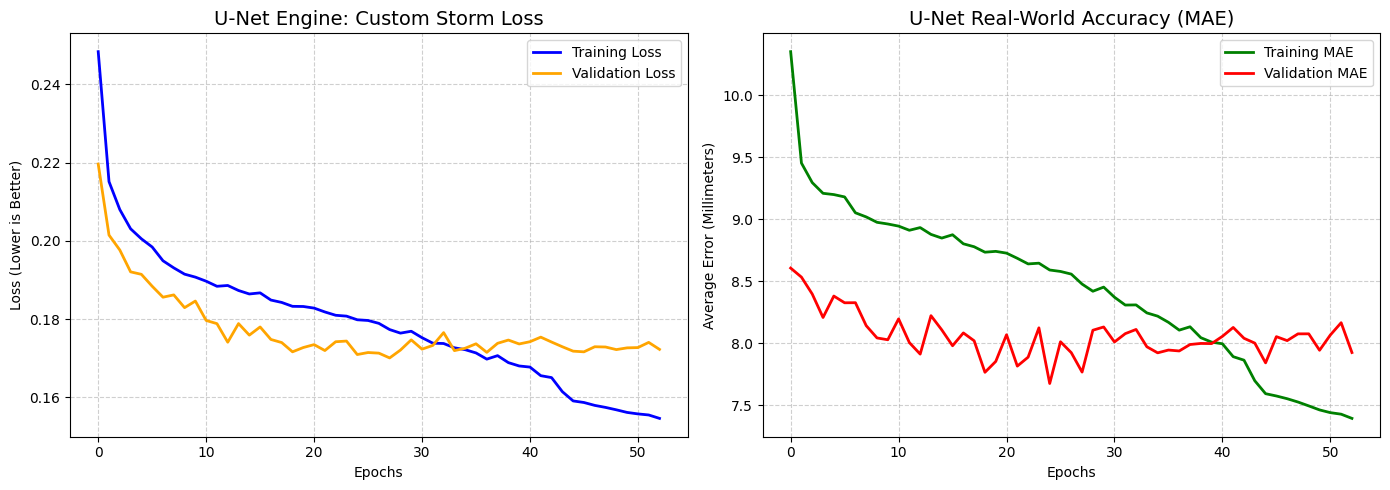

In [18]:
import matplotlib.pyplot as plt

print("--- EVALUATING U-NET LEARNING CURVES ---")

# Set up a wide canvas for side-by-side plots
plt.figure(figsize=(14, 5))

# --- PLOT 1: The Loss Curve (The AI's Internal Grade) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('U-Net Engine: Custom Storm Loss', fontsize=14)
plt.ylabel('Loss (Lower is Better)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: The MAE Curve (The Real-World Error in mm) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['mae_mm_wet'], label='Training MAE', color='green', linewidth=2)
plt.plot(history.history['val_mae_mm_wet'], label='Validation MAE', color='red', linewidth=2)
plt.title('U-Net Real-World Accuracy (MAE)', fontsize=14)
plt.ylabel('Average Error (Millimeters)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [34]:
# ══════════════════════════════════════════════════════════════
#  ADD AT THE END OF YOUR TRAINING NOTEBOOK (notebookdeb4e4ce54)
#  On Kaggle, all outputs must go to /kaggle/working/
#  After running, save them via: Output tab → "Save Version"
# ══════════════════════════════════════════════════════════════

import pickle
import numpy as np

SAVE_DIR = '/kaggle/working/'

# 1. Save the model weights
model.save(SAVE_DIR + 'mahanadi_cnnlstm_unet11.keras')
print("✅ Model saved.")

# 2. Save the fitted scalers
with open(SAVE_DIR + 'scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

with open(SAVE_DIR + 'scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("✅ Scalers saved.")

# 3. Save y_clean (winsorized IMD rainfall — avoids recomputing in prediction)
np.save(SAVE_DIR + 'y_clean.npy', y_clean)
print("✅ y_clean saved.")

print()
print("Files written to /kaggle/working/:")
print("   mahanadi_cnnlstm_unet10.keras")
print("   scaler_X.pkl")
print("   scaler_y.pkl")
print("   y_clean.npy")
print()
print("👉 Next: Click 'Save Version' (top right) → 'Save & Run All'")
print("   Then go to Output tab and click 'New Dataset' to publish these as a dataset.")

✅ Model saved.
✅ Scalers saved.
✅ y_clean saved.

Files written to /kaggle/working/:
   mahanadi_cnnlstm_unet10.keras
   scaler_X.pkl
   scaler_y.pkl
   y_clean.npy

👉 Next: Click 'Save Version' (top right) → 'Save & Run All'
   Then go to Output tab and click 'New Dataset' to publish these as a dataset.


--- LOADING GOLDEN WEIGHTS & GENERATING MAPS ---
✅ Golden weights successfully loaded!
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step
Sample 610 starts on: 2024-07-16
Predicting rainfall for: 2024-07-23 to 2024-07-25


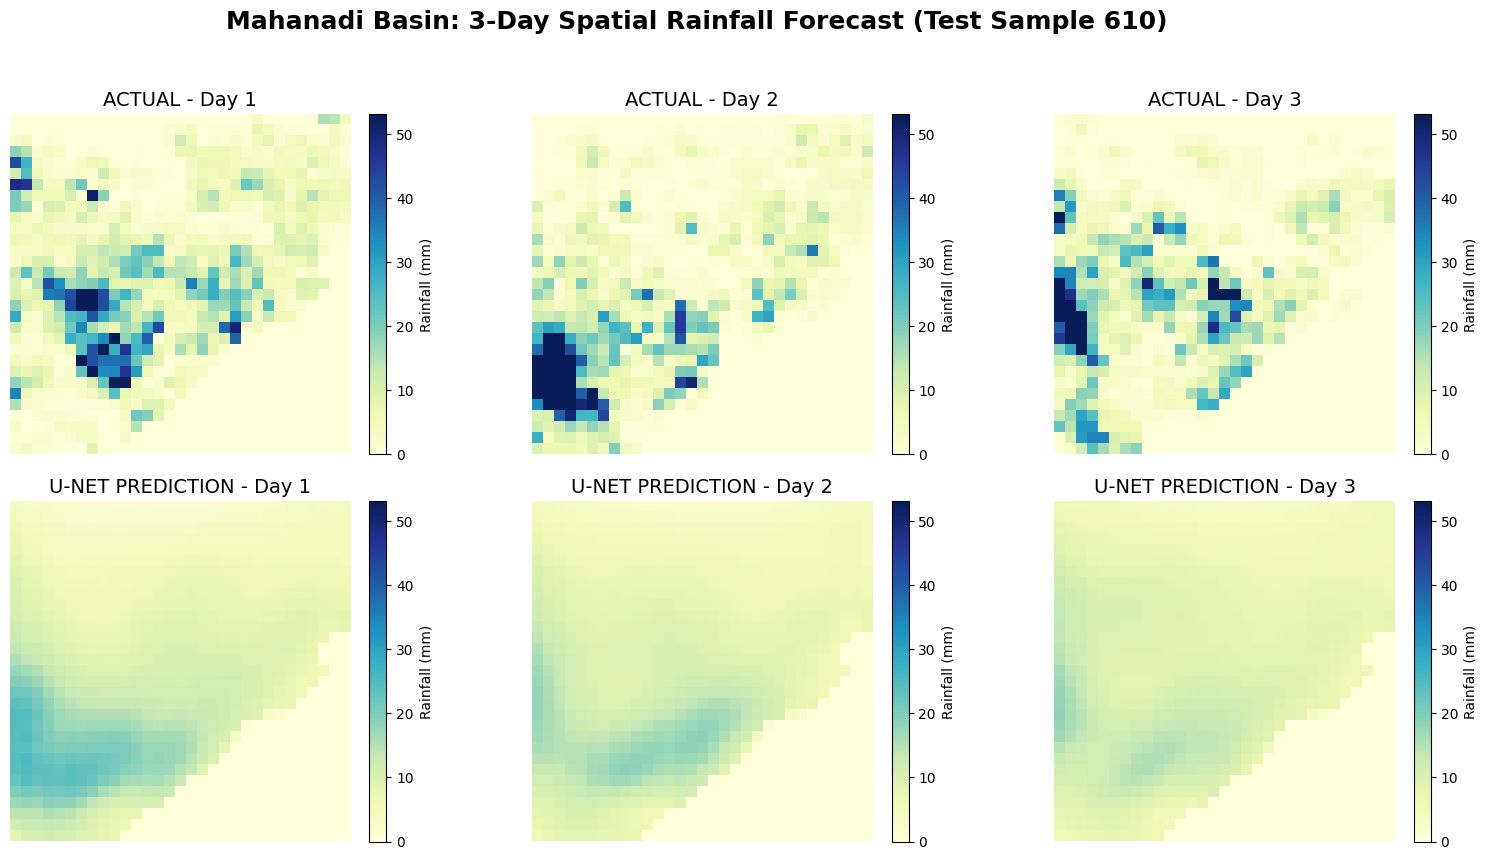


Average Error across these 3 days for Sample 610: 5.85 mm


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- LOADING GOLDEN WEIGHTS & GENERATING MAPS ---")

# 1. Build the empty brain using the function you already ran in Step 1
model = build_cnn_lstm_unet()

# 2. Inject the perfect numbers (This completely bypasses all Keras errors!)
save_path = '/kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras'
model.load_weights(save_path)
print("✅ Golden weights successfully loaded!")

# 3. Ask the freshly loaded AI to predict the test set
predicted_scaled = model.predict(X_test_seq)

# 4. Unscale the decimals back to real-world millimeters
def unscale_4d_tensor(tensor_4d, scaler):
    flat_tensor = tensor_4d.reshape(-1, 1)
    real_mm_flat = scaler.inverse_transform(flat_tensor)
    return real_mm_flat.reshape(tensor_4d.shape)

pred_mm = unscale_4d_tensor(predicted_scaled, scaler_y)
actual_mm = unscale_4d_tensor(y_test_seq, scaler_y)

# Clean up any tiny negative noise the AI might output
pred_mm = np.clip(pred_mm, a_min=0.0, a_max=None)

# 5. Plotting the 2x3 Grid
SAMPLE = 610  # Looking at Sample 110!

test_start_day = int(7670 * 0.85)  # = 6519
actual_date = pd.Timestamp('2005-01-01') + pd.Timedelta(days=test_start_day + test_ind[SAMPLE])
print(f"Sample {SAMPLE} starts on: {actual_date.date()}")
print(f"Predicting rainfall for: {(actual_date + pd.Timedelta(days=7)).date()} to {(actual_date + pd.Timedelta(days=9)).date()}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Mahanadi Basin: 3-Day Spatial Rainfall Forecast (Test Sample {SAMPLE})', fontsize=18, fontweight='bold')

for d in range(3):
    vmax = max(actual_mm[SAMPLE, d].max(), pred_mm[SAMPLE, d].max())
    if vmax == 0: vmax = 1.0

    # -- TOP ROW: ACTUAL RAINFALL --
    im_actual = axes[0, d].imshow(actual_mm[SAMPLE, d], cmap='YlGnBu', vmin=0, vmax=vmax, origin='lower')
    axes[0, d].set_title(f'ACTUAL - Day {d+1}', fontsize=14)
    axes[0, d].axis('off')
    plt.colorbar(im_actual, ax=axes[0, d], fraction=0.046, pad=0.04, label='Rainfall (mm)')

    # -- BOTTOM ROW: U-NET PREDICTION --
    im_pred = axes[1, d].imshow(pred_mm[SAMPLE, d], cmap='YlGnBu', vmin=0, vmax=vmax, origin='lower')
    axes[1, d].set_title(f'U-NET PREDICTION - Day {d+1}', fontsize=14)
    axes[1, d].axis('off')
    plt.colorbar(im_pred, ax=axes[1, d], fraction=0.046, pad=0.04, label='Rainfall (mm)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

mean_error_mm = np.mean(np.abs(actual_mm[SAMPLE] - pred_mm[SAMPLE]))
print(f"\nAverage Error across these 3 days for Sample {SAMPLE}: {mean_error_mm:.2f} mm")

--- RUNNING GLOBAL ARTIFACT DIAGNOSTIC ON TEST SPLIT ---


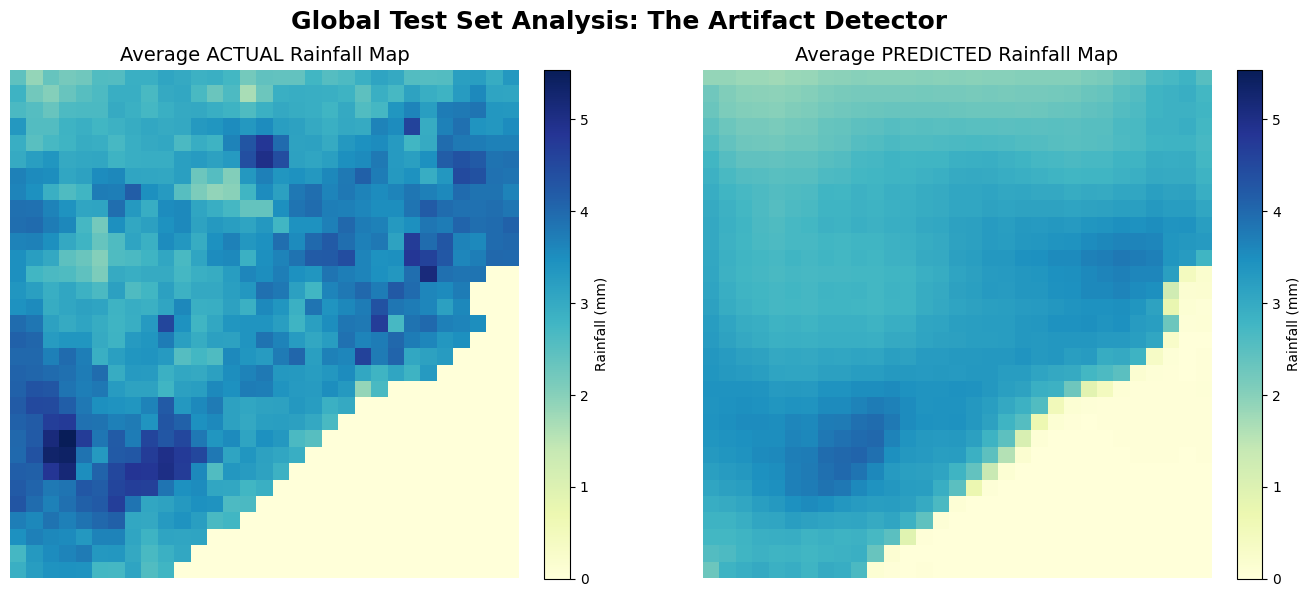

In [20]:
import numpy as np
import matplotlib.pyplot as plt

print("--- RUNNING GLOBAL ARTIFACT DIAGNOSTIC ON TEST SPLIT ---")

# 1. Calculate the average rainfall across ALL samples and ALL 3 days
mean_actual_map = np.mean(actual_mm, axis=(0, 1))
mean_pred_map = np.mean(pred_mm, axis=(0, 1))

# 2. Plot the Artifact Detector
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Global Test Set Analysis: The Artifact Detector', fontsize=18, fontweight='bold')

# Ensure colorbars match for fair comparison
vmax = max(mean_actual_map.max(), mean_pred_map.max())

# Plot 1: What the rain actually looks like on average
im1 = axes[0].imshow(mean_actual_map, cmap='YlGnBu', vmin=0, vmax=vmax, origin='lower')
axes[0].set_title('Average ACTUAL Rainfall Map', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Rainfall (mm)')

# Plot 2: What the AI thinks the rain looks like on average
im2 = axes[1].imshow(mean_pred_map, cmap='YlGnBu', vmin=0, vmax=vmax, origin='lower')
axes[1].set_title('Average PREDICTED Rainfall Map', fontsize=14)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Rainfall (mm)')

plt.tight_layout()
plt.show()

  Model   : mahanadi_cnnlstm_unet10.keras
  Target  : 2024-08-30 → 2024-09-01
  Lookback: 2024-08-23 → 2024-08-29
  🟡 WAY 2 — Val/Test range  |  actual IMD available  |  model NEVER saw these dates (blind test)
  Dataset : 2005-01-01 → 2025-12-31
  Training: 2005-01-01 → 2019-09-13

✅ Model weights loaded.
✅ Lookback input: X_features[7174:7181]  (2024-08-23 → 2024-08-29)
✅ Prediction complete.
✅ Actual IMD data: y_clean[7181:7184]  (2024-08-30 → 2024-09-01)


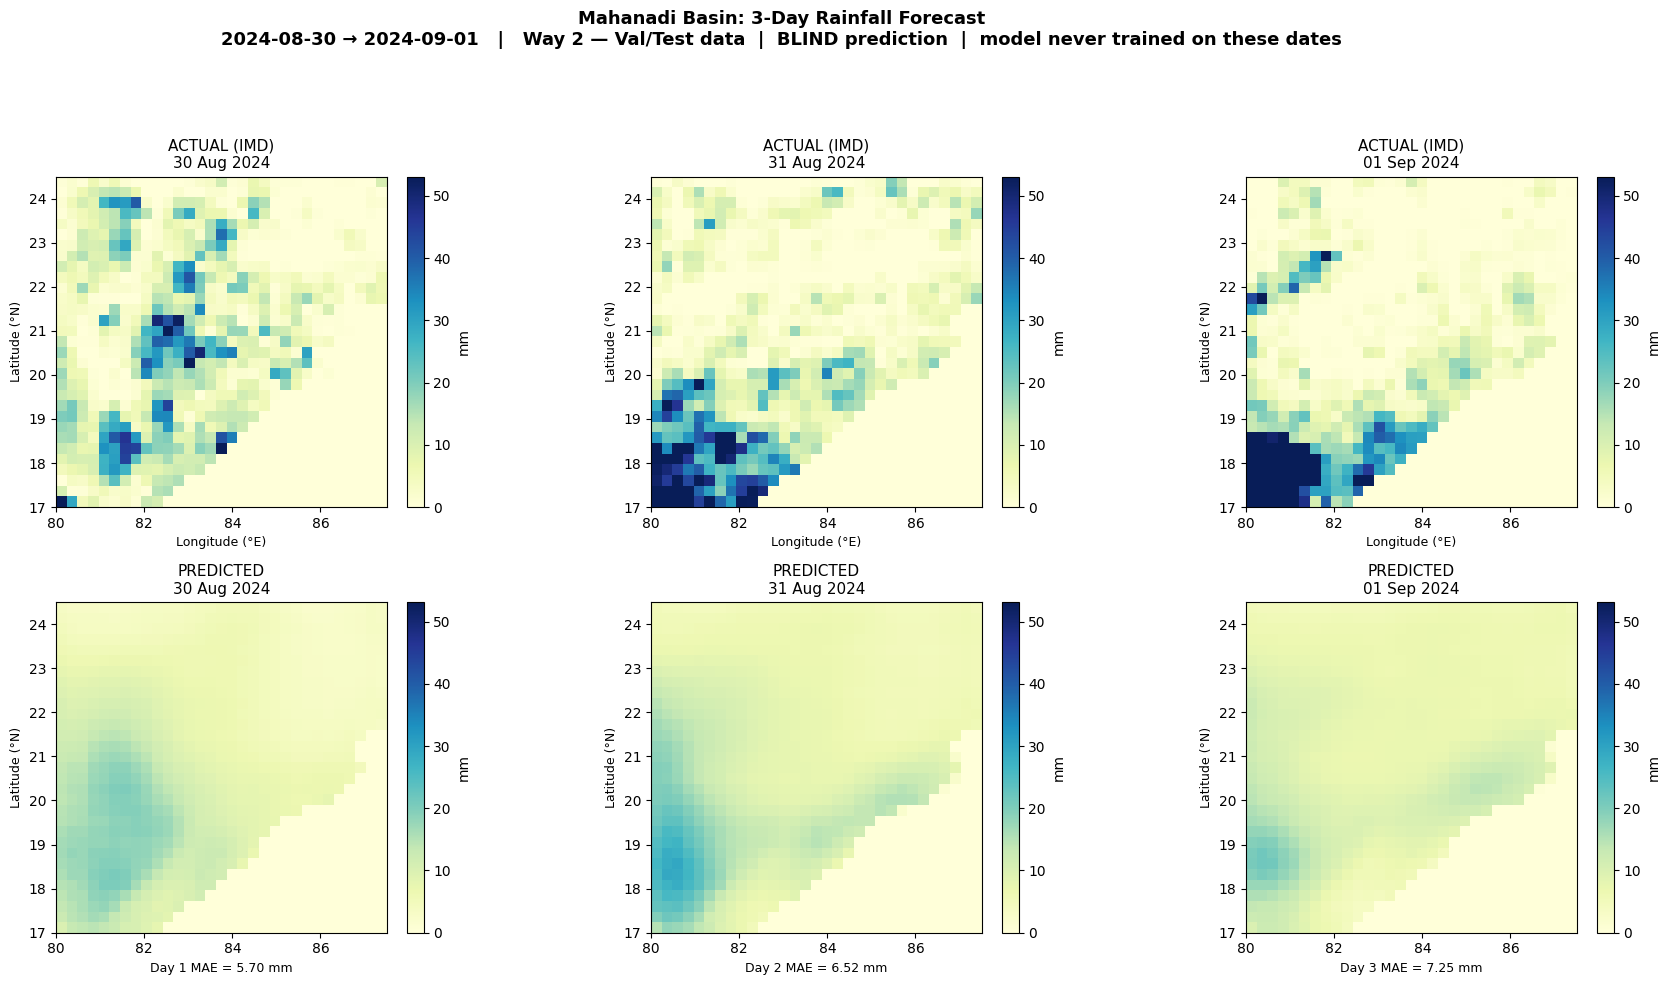


📊 Basin-average results:
  Date            Pred mean   Pred max  Actual mean    Day MAE
  ──────────────────────────────────────────────────────────────────────
  2024-08-30           7.05      20.50         7.21       5.70
  2024-08-31           7.92      29.23         7.61       6.52
  2024-09-01           6.83      21.44         6.79       7.25

  Overall 3-day MAE: 6.49 mm

  ℹ️  WAY 2 note: these dates (2024-08-30 → 2024-09-01)
     were NOT used during training. This is a genuine blind evaluation.
     For a 'fair' comparison the model saw, use a date before 2019-09-13.


In [31]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║           CELL 31 — SMART PREDICTION ENGINE (FINAL v3)          ║
# ╠══════════════════════════════════════════════════════════════════╣
# ║  Dataset date boundaries (7670 days from 2005-01-01):           ║
# ║    TRAIN  2005-01-01 → 2019-09-13  (days   0 – 5368)           ║
# ║    VAL    2019-09-14 → 2022-11-06  (days 5369 – 6518)          ║
# ║    TEST   2022-11-07 → 2025-12-31  (days 6519 – 7669)          ║
# ║                                                                  ║
# ║  WAY 1 — Target inside TRAIN range (2005-01-01 → 2019-09-13)   ║
# ║    Lookback : X_features[idx-7 : idx]    (already loaded)       ║
# ║    Actual   : y_clean[idx : idx+3]       (already loaded)       ║
# ║    Plot     : ACTUAL (top row) + PREDICTED (bottom row) + MAE   ║
# ║                                                                  ║
# ║  WAY 2 — Target inside VAL/TEST range (2019-09-14 → 2025-12-31)║
# ║    Lookback : X_features[idx-7 : idx]    (data exists on disk)  ║
# ║    Actual   : y_clean[idx : idx+3]       (IMD data exists)      ║
# ║    Plot     : ACTUAL (top row) + PREDICTED (bottom row) + MAE   ║
# ║    Note: model never trained on these dates → genuine blind test ║
# ║                                                                  ║
# ║  WAY 3 — Target beyond dataset (after 2025-12-31)               ║
# ║    Lookback : climatological mean of X_train (no real data)     ║
# ║    Actual   : not available                                      ║
# ║    Plot     : PREDICTED only                                     ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ── ✏️  ONLY CHANGE THIS LINE ────────────────────────────────────
TARGET_START_DATE = '2024-08-30'   # first of the 3 forecast days
# ─────────────────────────────────────────────────────────────────

MODEL_WEIGHTS = '/kaggle/working/mahanadi-rainfall/mahanadi_cnnlstm_unet10.keras'

# ── Dataset constants (derived from your Cell 23) ───────────────
DATASET_START = pd.Timestamp('2005-01-01')
TOTAL_DAYS    = 7670
TRAIN_END     = int(TOTAL_DAYS * 0.70)   # 5369  → 2019-09-13
VAL_END       = int(TOTAL_DAYS * 0.85)   # 6519  → 2022-11-06
DATASET_END   = TOTAL_DAYS - 1           # 7669  → 2025-12-31

TRAIN_END_DATE   = DATASET_START + pd.Timedelta(days=TRAIN_END - 1)
DATASET_END_DATE = DATASET_START + pd.Timedelta(days=DATASET_END)

LOOKBACK = 7
HORIZON  = 3
LAT_MIN, LAT_MAX = 17.0, 24.5
LON_MIN, LON_MAX = 80.0, 87.5
GRID_H, GRID_W   = 31, 31

# ── Resolve dates → indices ──────────────────────────────────────
target_start       = pd.Timestamp(TARGET_START_DATE)
lookback_start     = target_start - pd.Timedelta(days=LOOKBACK)
target_end         = target_start + pd.Timedelta(days=HORIZON - 1)

lookback_start_idx = (lookback_start - DATASET_START).days
target_start_idx   = (target_start   - DATASET_START).days
target_end_idx     = (target_end     - DATASET_START).days

# ── Determine WAY ────────────────────────────────────────────────
lookback_available = (lookback_start_idx >= 0) and \
                     (lookback_start_idx + LOOKBACK <= TOTAL_DAYS)

target_available   = (target_start_idx >= 0) and \
                     (target_end_idx   <= DATASET_END)

if not lookback_available:
    WAY = 3   # Even lookback window is beyond dataset
elif target_available and target_end_idx < TRAIN_END:
    WAY = 1   # Both lookback and target fully inside training range
elif target_available:
    WAY = 2   # Val/Test range — lookback + actual exist, but model never saw these dates
else:
    WAY = 3   # Target is beyond dataset end date

# ── Print header ─────────────────────────────────────────────────
WAY_DESCRIPTIONS = {
    1: "🟢 WAY 1 — Training range  |  actual IMD available  |  model SAW these dates",
    2: "🟡 WAY 2 — Val/Test range  |  actual IMD available  |  model NEVER saw these dates (blind test)",
    3: "🔵 WAY 3 — Beyond dataset  |  no actual data        |  climatology input",
}
print(f"{'='*65}")
print(f"  Model   : {MODEL_WEIGHTS.split('/')[-1]}")
print(f"  Target  : {target_start.date()} → {target_end.date()}")
print(f"  Lookback: {lookback_start.date()} → {(target_start - pd.Timedelta(days=1)).date()}")
print(f"{'='*65}")
print(f"  {WAY_DESCRIPTIONS[WAY]}")
print(f"{'='*65}")
print(f"  Dataset : {DATASET_START.date()} → {DATASET_END_DATE.date()}")
print(f"  Training: {DATASET_START.date()} → {TRAIN_END_DATE.date()}")
print()

# ── STEP 1: LOAD MODEL ───────────────────────────────────────────
model = build_cnn_lstm_unet()
model.load_weights(MODEL_WEIGHTS)
print("✅ Model weights loaded.")

# ── STEP 2: BUILD LOOKBACK INPUT ────────────────────────────────
if WAY in (1, 2):
    # Both WAY 1 and WAY 2 have lookback data in X_features
    # This is the SAME ERA5 data your model was trained on — exact same format
    X_window_raw    = X_features[lookback_start_idx : lookback_start_idx + LOOKBACK]
    # shape: (7, 31, 31, 5) — raw ERA5 units (K, Pa, kg/kg, m/s, m/s)
    X_window_scaled = scale_array(X_window_raw, scaler_X, fit=False)
    print(f"✅ Lookback input: X_features[{lookback_start_idx}:{lookback_start_idx + LOOKBACK}]"
          f"  ({lookback_start.date()} → {(target_start - pd.Timedelta(days=1)).date()})")
else:
    # WAY 3 — no real data, use mean of training X as neutral input
    X_clim          = np.mean(X_train, axis=0)                # (31, 31, 5)
    X_window_scaled = np.stack([X_clim] * LOOKBACK, axis=0)   # (7, 31, 31, 5)
    print("⚠️  Lookback: using training climatological mean (no real data available)")

X_input = X_window_scaled[np.newaxis, ...]    # (1, 7, 31, 31, 5)

# ── STEP 3: PREDICT ─────────────────────────────────────────────
predicted_scaled = model.predict(X_input, verbose=0)   # (1, 3, 31, 31)
predicted_scaled = np.clip(predicted_scaled, 0, None)

def unscale(arr, scaler):
    return scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

pred_mm = unscale(predicted_scaled[0], scaler_y)       # (3, 31, 31) in mm
print("✅ Prediction complete.")

# ── STEP 4: GET ACTUAL IMD RAINFALL ─────────────────────────────
# WAY 1 and WAY 2 both have actual IMD data in y_clean
# y_clean is the full winsorized IMD array for all 7670 days
has_actual = False
if WAY in (1, 2):
    actual_raw = y_clean[target_start_idx : target_start_idx + HORIZON]
    if actual_raw.shape[0] == HORIZON:
        actual_mm  = actual_raw   # (3, 31, 31) in mm
        has_actual = True
        print(f"✅ Actual IMD data: y_clean[{target_start_idx}:{target_start_idx + HORIZON}]"
              f"  ({target_start.date()} → {target_end.date()})")
    else:
        print("⚠️  Could not slice actual IMD data — index out of bounds.")

# ── STEP 5: PLOT ─────────────────────────────────────────────────
n_rows     = 2 if has_actual else 1
row_labels = ['ACTUAL (IMD)', 'PREDICTED'] if has_actual else ['PREDICTED']
data_rows  = [actual_mm, pred_mm]          if has_actual else [pred_mm]

way_title = {
    1: "Way 1 — Training data  |  model SAW these dates",
    2: "Way 2 — Val/Test data  |  BLIND prediction  |  model never trained on these dates",
    3: "Way 3 — Future date    |  climatology input",
}

fig, axes = plt.subplots(n_rows, HORIZON,
                          figsize=(6 * HORIZON, 5 * n_rows),
                          squeeze=False)

fig.suptitle(
    f"Mahanadi Basin: 3-Day Rainfall Forecast\n"
    f"{target_start.date()} → {target_end.date()}   |   {way_title[WAY]}",
    fontsize=13, fontweight='bold'
)

for row_i, (label, maps) in enumerate(zip(row_labels, data_rows)):
    for d in range(HORIZON):
        ax       = axes[row_i, d]
        day_date = target_start + pd.Timedelta(days=d)

        vmax = max(
            float(actual_mm[d].max()) if has_actual else 0.0,
            float(pred_mm[d].max()),
            1.0
        )

        im = ax.imshow(
            maps[d], cmap='YlGnBu',
            vmin=0, vmax=vmax, origin='lower',
            extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
        )
        ax.set_title(f"{label}\n{day_date.strftime('%d %b %Y')}", fontsize=11)
        ax.set_xlabel("Longitude (°E)", fontsize=9)
        ax.set_ylabel("Latitude (°N)",  fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mm')

        # Show per-day MAE on the PREDICTED row
        if has_actual and label == 'PREDICTED':
            mae = float(np.mean(np.abs(actual_mm[d] - pred_mm[d])))
            ax.set_xlabel(f"Day {d+1} MAE = {mae:.2f} mm", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# ── STEP 6: PRINT SUMMARY ────────────────────────────────────────
print("\n📊 Basin-average results:")
print(f"  {'Date':<14} {'Pred mean':>10} {'Pred max':>10}"
      + (f" {'Actual mean':>12} {'Day MAE':>10}" if has_actual else ""))
print("  " + "─" * (46 + (24 if has_actual else 0)))

for d in range(HORIZON):
    day_date  = target_start + pd.Timedelta(days=d)
    pm        = float(np.mean(pred_mm[d]))
    px        = float(np.max(pred_mm[d]))
    line      = f"  {str(day_date.date()):<14} {pm:>10.2f} {px:>10.2f}"
    if has_actual:
        am  = float(np.mean(actual_mm[d]))
        mae = float(np.mean(np.abs(actual_mm[d] - pred_mm[d])))
        line += f" {am:>12.2f} {mae:>10.2f}"
    print(line)

if has_actual:
    overall = float(np.mean(np.abs(actual_mm - pred_mm)))
    print(f"\n  Overall 3-day MAE: {overall:.2f} mm")

if WAY == 2:
    print(f"\n  ℹ️  WAY 2 note: these dates ({target_start.date()} → {target_end.date()})")
    print(f"     were NOT used during training. This is a genuine blind evaluation.")
    print(f"     For a 'fair' comparison the model saw, use a date before {TRAIN_END_DATE.date()}.")
elif WAY == 3:
    print(f"\n  ℹ️  WAY 3 note: target date is beyond the dataset ({DATASET_END_DATE.date()}).")
    print(f"     Prediction is based on climatological mean — not real weather input.")

In [32]:
def predict_at_location(lat, lon):
    """
    Given a lat/lon, finds the nearest grid point, then looks at all
    grid pixels within ±1 degree, and reports:
      - max predicted rainfall in that area
      - mean predicted rainfall in that area  
      - max actual rainfall in that area (WAY 1 or WAY 2 only)
    for each of the 3 forecast days.

    pred_mm, actual_mm, has_actual, target_start, HORIZON
    must already exist in scope from Cell 31.
    """

    LATS = np.linspace(17.0, 24.5, 31)
    LONS = np.linspace(80.0, 87.5, 31)

    # ── Step 1: find nearest grid point ─────────────────────────
    nearest_row = int(np.argmin(np.abs(LATS - lat)))
    nearest_col = int(np.argmin(np.abs(LONS - lon)))
    nearest_lat = LATS[nearest_row]
    nearest_lon = LONS[nearest_col]

    # ── Step 2: find all pixels within ±1 degree of that point ──
    row_mask = np.abs(LATS - nearest_lat) <= 1.0
    col_mask = np.abs(LONS - nearest_lon) <= 1.0

    row_indices = np.where(row_mask)[0]
    col_indices = np.where(col_mask)[0]

    # Build 2D boolean mask over the full grid
    area_mask = np.zeros((31, 31), dtype=bool)
    for r in row_indices:
        for c in col_indices:
            area_mask[r, c] = True

    # ── Step 3: Print results ────────────────────────────────────
    print(f"\nQuery     : {lat:.2f}°N, {lon:.2f}°E")
    print(f"Nearest   : {nearest_lat:.2f}°N, {nearest_lon:.2f}°E")
    print(f"Area      : {nearest_lat-1:.2f}–{nearest_lat+1:.2f}°N, "
          f"{nearest_lon-1:.2f}–{nearest_lon+1:.2f}°E  "
          f"({area_mask.sum()} pixels)")
    print()

    if has_actual:
        print(f"  {'Date':<14} {'Max pred':>10} {'Mean pred':>10} {'Max actual':>11}")
        print(f"  {'─'*50}")
    else:
        print(f"  {'Date':<14} {'Max pred':>10} {'Mean pred':>10}")
        print(f"  {'─'*37}")

    for d in range(HORIZON):
        day_date = target_start + pd.Timedelta(days=d)

        area_pred   = pred_mm[d][area_mask]
        max_pred    = float(area_pred.max())
        mean_pred   = float(area_pred.mean())

        if has_actual:
            area_actual = actual_mm[d][area_mask]
            max_actual  = float(area_actual.max())
            print(f"  {str(day_date.date()):<14} {max_pred:>9.2f}  "
                  f"{mean_pred:>9.2f}  {max_actual:>10.2f}")
        else:
            print(f"  {str(day_date.date()):<14} {max_pred:>9.2f}  {mean_pred:>9.2f}")

    print()


# ── Call it for any location you want ───────────────────────────
predict_at_location(20.5, 83.5)
predict_at_location(22.0, 82.0)
predict_at_location(19.0, 85.0)


Query     : 20.50°N, 83.50°E
Nearest   : 20.50°N, 83.50°E
Area      : 19.50–21.50°N, 82.50–84.50°E  (81 pixels)

  Date             Max pred  Mean pred  Max actual
  ──────────────────────────────────────────────────
  2024-08-30         17.16       9.27       53.12
  2024-08-31         13.75       8.66       34.78
  2024-09-01         11.99       8.33       18.52


Query     : 22.00°N, 82.00°E
Nearest   : 22.00°N, 82.00°E
Area      : 21.00–23.00°N, 81.00–83.00°E  (81 pixels)

  Date             Max pred  Mean pred  Max actual
  ──────────────────────────────────────────────────
  2024-08-30         17.27      10.20       53.12
  2024-08-31         13.43       9.71       11.99
  2024-09-01          9.79       8.01       53.12


Query     : 19.00°N, 85.00°E
Nearest   : 19.00°N, 85.00°E
Area      : 18.00–20.00°N, 84.00–86.00°E  (81 pixels)

  Date             Max pred  Mean pred  Max actual
  ──────────────────────────────────────────────────
  2024-08-30         10.98       3.35       

In [33]:
def predict_at_location(lat, lon):
    """
    Given a lat/lon:
    1. Finds the nearest grid point
    2. Selects all pixels within ±1 degree of that nearest point
    3. For each of the 3 forecast days, finds the pixel with MAX predicted
       rainfall inside that rectangle and reports its coordinates,
       along with max pred, mean pred, and max actual at that same pixel.
    """

    LATS = np.linspace(17.0, 24.5, 31)
    LONS = np.linspace(80.0, 87.5, 31)

    # ── Step 1: nearest grid point ───────────────────────────────
    nearest_row = int(np.argmin(np.abs(LATS - lat)))
    nearest_col = int(np.argmin(np.abs(LONS - lon)))
    nearest_lat = LATS[nearest_row]
    nearest_lon = LONS[nearest_col]

    # ── Step 2: all row/col indices within ±1 degree ─────────────
    row_indices = np.where(np.abs(LATS - nearest_lat) <= 1.0)[0]
    col_indices = np.where(np.abs(LONS - nearest_lon) <= 1.0)[0]

    # Sub-grid slice boundaries (for efficient indexing)
    r_min, r_max = row_indices[0],  row_indices[-1]
    c_min, c_max = col_indices[0],  col_indices[-1]

    n_pixels = len(row_indices) * len(col_indices)

    # ── Step 3: Print header ─────────────────────────────────────
    print(f"Query     : {lat:.2f}°N, {lon:.2f}°E")
    print(f"Nearest   : {nearest_lat:.2f}°N, {nearest_lon:.2f}°E")
    print(f"Area      : {LATS[r_min]:.2f}–{LATS[r_max]:.2f}°N, "
          f"{LONS[c_min]:.2f}–{LONS[c_max]:.2f}°E  ({n_pixels} pixels)")
    print()

    if has_actual:
        print(f"  {'Date':<14} {'Max coord':>18} {'Max pred':>10} "
              f"{'Mean pred':>10} {'Actual @ max':>13}")
        print(f"  {'─'*70}")
    else:
        print(f"  {'Date':<14} {'Max coord':>18} {'Max pred':>10} {'Mean pred':>10}")
        print(f"  {'─'*57}")

    # ── Step 4: Per-day analysis ─────────────────────────────────
    for d in range(HORIZON):
        day_date = target_start + pd.Timedelta(days=d)

        # Extract the sub-grid patch for predicted rainfall
        pred_patch = pred_mm[d, r_min:r_max+1, c_min:c_max+1]
        # shape: (n_rows_in_area, n_cols_in_area)

        # Find position of max predicted value within the patch
        flat_idx        = int(np.argmax(pred_patch))
        local_row, local_col = np.unravel_index(flat_idx, pred_patch.shape)

        # Convert back to global grid indices
        global_row = r_min + local_row
        global_col = c_min + local_col

        # Real-world coordinates of the max pixel
        max_lat = LATS[global_row]
        max_lon = LONS[global_col]

        max_pred  = float(pred_patch[local_row, local_col])
        mean_pred = float(pred_patch.mean())

        coord_str = f"({max_lat:.2f}°N,{max_lon:.2f}°E)"

        if has_actual:
            # Actual value at the SAME pixel that had max predicted rainfall
            actual_at_max = float(actual_mm[d, global_row, global_col])
            print(f"  {str(day_date.date()):<14} {coord_str:>18} {max_pred:>10.2f} "
                  f"{mean_pred:>10.2f} {actual_at_max:>12.2f}")
        else:
            print(f"  {str(day_date.date()):<14} {coord_str:>18} {max_pred:>10.2f} "
                  f"{mean_pred:>10.2f}")

    print()


# ── Call it ──────────────────────────────────────────────────────
predict_at_location(20.5, 83.5)
predict_at_location(22.0, 82.0)
predict_at_location(19.0, 85.0)

Query     : 20.50°N, 83.50°E
Nearest   : 20.50°N, 83.50°E
Area      : 19.50–21.50°N, 82.50–84.50°E  (81 pixels)

  Date                    Max coord   Max pred  Mean pred  Actual @ max
  ──────────────────────────────────────────────────────────────────────
  2024-08-30      (19.50°N,82.50°E)      17.16       9.27        16.45
  2024-08-31      (19.50°N,84.50°E)      13.75       8.66        22.55
  2024-09-01      (20.00°N,84.50°E)      11.99       8.33         7.94

Query     : 22.00°N, 82.00°E
Nearest   : 22.00°N, 82.00°E
Area      : 21.00–23.00°N, 81.00–83.00°E  (81 pixels)

  Date                    Max coord   Max pred  Mean pred  Actual @ max
  ──────────────────────────────────────────────────────────────────────
  2024-08-30      (21.00°N,81.25°E)      17.27      10.20         3.83
  2024-08-31      (21.25°N,81.00°E)      13.43       9.71         3.10
  2024-09-01      (21.75°N,81.00°E)       9.79       8.01         9.48

Query     : 19.00°N, 85.00°E
Nearest   : 19.00°N, 85.00°